In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import RobustScaler, StandardScaler

from typing import List, Dict
from tqdm import tqdm
from matplotlib import pyplot as plt
from pathlib import Path

In [2]:
df = pd.read_parquet("data/sazerac_sales_prepared.parquet")
# df.replace([np.inf, -np.inf], np.nan, inplace=True)

In [3]:
# Filter stores with at least 30 records
store_counts = df.groupby('store').size()
valid_stores = store_counts[store_counts >= 70].index
df = df[df['store'].isin(valid_stores)]

<Axes: >

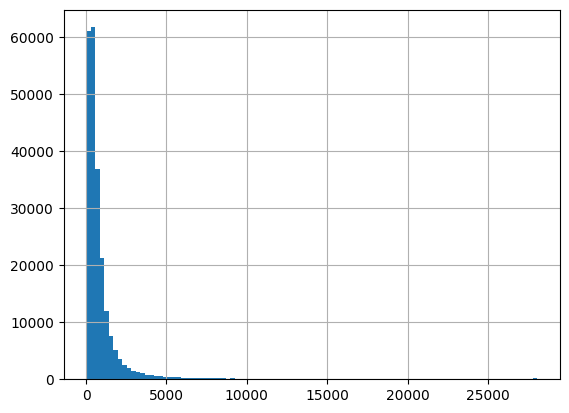

In [4]:
df['sale_dollars'] = np.where(df['sale_dollars'] < 0, 
                              0, 
                              df['sale_dollars'])
df['sale_dollars'] = np.where(df['sale_dollars'] > df['sale_dollars'].quantile(0.999), 
                              df['sale_dollars'].quantile(0.999), 
                              df['sale_dollars'])

df['sale_dollars'].hist(bins=100)

In [5]:
STATIC_CATEGORICAL = [
    "name", "address", "city", "zipcode", "county",
]

STATIC_NUM = [
    "lon", "lat",
]

DYNAMIC = [
    "sale_bottles", "sale_bottles_mean", "sale_bottles_median", "sale_bottles_min", "sale_bottles_max",
    "sale_dollars", "sale_dollars_mean", "sale_dollars_median", "sale_dollars_min", "sale_dollars_max",
    "sale_liters", "sale_liters_mean", "sale_liters_median", "sale_liters_min", "sale_liters_max",
    "transaction_count",
    "state_bottle_cost_mean", "state_bottle_cost_median", "state_bottle_cost_min", "state_bottle_cost_max",
    "state_bottle_retail_mean", "state_bottle_retail_median", "state_bottle_retail_min", "state_bottle_retail_max",
    "avg_price_per_bottle", "avg_price_per_liter", "profit_margin", "discount_factor",
    "unique_categories", "unique_items",
    "pack_mean", "pack_median", "pack_min", "pack_max", "pack_sum",
    "bottle_volume_ml_mean", "bottle_volume_ml_median", "bottle_volume_ml_min", "bottle_volume_ml_max", "bottle_volume_ml_sum",
    "days_since_prev_purchase",
    "day_of_week_sin", "day_of_week_cos", "day_of_month_sin", "day_of_month_cos",
    "month_sin", "month_cos", "quarter_sin", "quarter_cos", "week_of_year_sin", "week_of_year_cos",
    "year", "is_weekend", "is_holiday", "days_to_nearest_holiday",
    "prev_1_purchase_sale_dollars", "prev_2_purchase_sale_dollars", "prev_3_purchase_sale_dollars", "prev_4_purchase_sale_dollars",
    "store_avg_sales", "store_avg_transactions", "store_avg_items", "store_size",
    "city_avg_sales", "county_avg_sales", "store_to_city_sales_ratio", "store_to_county_sales_ratio",
]

# Add rolling window features
for w in [2, 4, 8, 12, 30, 60, 90]:
    for stat in ["mean", "std", "max", "min", "median"]:
        DYNAMIC.append(f"hist_{stat}_{w}_purchases_sale_dollars")
    DYNAMIC.extend([
        f"purchase_momentum_{w}",
        f"purchase_momentum_pct_{w}",
        f"hist_avg_days_between_purchases_{w}",
    ])

TARGET = ["sale_dollars"]

In [6]:
class FeaturePreprocessor:
    def __init__(self, static_cat_cols: List[str], static_num_cols: List[str], 
                 dynamic_cols: List[str], target_cols: List[str]):
        self.static_cat_cols = static_cat_cols
        self.static_num_cols = static_num_cols
        self.dynamic_cols = dynamic_cols
        self.target_cols = target_cols
        
        # Scalers for numerical features
        self.static_scaler = StandardScaler()
        self.dynamic_scaler = StandardScaler()
        self.target_scaler = StandardScaler()
        
        # Category encodings
        self.cat_encodings = {}
        self.padding_values = {}
        
    def fit(self, df: pd.DataFrame):
        # Handle categorical features
        for col in self.static_cat_cols:
            # Add special token for missing values
            unique_vals = df[col].dropna().unique()
            # 0 reserved for padding, 1 for unknown/missing
            self.cat_encodings[col] = {val: idx + 2 for idx, val in enumerate(unique_vals)}
            self.padding_values[col] = 0  # padding token
            
        # Fit scalers
        if self.static_num_cols:
            self.static_scaler.fit(df[self.static_num_cols])
        if self.dynamic_cols:
            self.dynamic_scaler.fit(df[self.dynamic_cols])
        if self.target_cols:
            self.target_scaler.fit(df[self.target_cols])
            
        return self
    
    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        
        # Transform categorical features
        for col in self.static_cat_cols:
            # Convert to numeric categories, using 1 for unknown values
            df[col] = df[col].map(lambda x: self.cat_encodings[col].get(x, 1))
            # Fill missing with padding token
            df[col] = df[col].fillna(self.padding_values[col])
            
        # Transform numerical features
        if self.static_num_cols:
            df[self.static_num_cols] = self.static_scaler.transform(df[self.static_num_cols])
            # Fill missing with 0 after scaling
            df[self.static_num_cols] = df[self.static_num_cols].fillna(0)
            
        if self.dynamic_cols:
            df[self.dynamic_cols] = self.dynamic_scaler.transform(df[self.dynamic_cols])
            # Fill missing with 0 after scaling
            df[self.dynamic_cols] = df[self.dynamic_cols].fillna(0)
            
        if self.target_cols:
            df[self.target_cols] = self.target_scaler.transform(df[self.target_cols])
            
        return df
    
    def inverse_transform_targets(self, y: np.ndarray) -> np.ndarray:
        return self.target_scaler.inverse_transform(y)

In [7]:
class SlidingWindowDataset(Dataset):
    def __init__(
            self, 
            df: pd.DataFrame, 
            preprocessor: FeaturePreprocessor, 
            seq_len: int = 30, 
            horizon: int = 30, 
            min_history: int = 10
    ):
        """
        Args:
            df: Input dataframe
            preprocessor: Fitted FeaturePreprocessor instance
            seq_len: Length of input sequence
            horizon: Prediction horizon
            min_history: Minimum number of historical points required
        """
        self.seq_len = seq_len
        self.horizon = horizon
        self.preprocessor = preprocessor
        sequences = []
        for _, group_df in self.preprocessor.transform(df).groupby("store"):
            if len(group_df) < (min_history + seq_len + horizon):
                continue
            group_df = group_df.set_index("date").sort_index()

            dynamic_data = group_df[preprocessor.dynamic_cols].values
            static_num_data = group_df[preprocessor.static_num_cols].values
            static_cat_data = group_df[preprocessor.static_cat_cols].values
            target_data = group_df[preprocessor.target_cols].values
            
            for i in range(len(group_df) - seq_len - horizon + 1):
                sequences.append({
                    'dynamic': dynamic_data[i:i+seq_len],
                    'static_num': static_num_data[i+seq_len-1],
                    'static_cat': static_cat_data[i+seq_len-1],
                    'target': target_data[i+seq_len:i+seq_len+horizon]
                })
        self.dynamic = torch.FloatTensor(np.stack([s['dynamic'] for s in sequences]))
        self.static_num = torch.FloatTensor(np.stack([s['static_num'] for s in sequences]))
        self.static_cat = torch.LongTensor(np.stack([s['static_cat'] for s in sequences]))
        self.target = torch.FloatTensor(np.stack([s['target'] for s in sequences]))
        self.attention_mask = torch.FloatTensor(np.ones((len(sequences), seq_len)))
        
    def __len__(self):
        return len(self.target)
    
    def __getitem__(self, idx):
        return {
            'dynamic': self.dynamic[idx],
            'static_num': self.static_num[idx],
            'static_cat': {
                col: self.static_cat[idx, i]
                for i, col in enumerate(self.preprocessor.static_cat_cols)
            },
            'attention_mask': self.attention_mask[idx],
            'target': self.target[idx]
        }

In [8]:
SEQ_LEN, HORIZON = 30, 30
BATCH_SIZE, LR, EPOCHS = 30, 1e-3, 10
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [9]:
store_ids = df['store'].unique()
np.random.shuffle(store_ids)

n = len(store_ids)
n_train = int(0.7 * n)
n_val   = int(0.15 * n)
n_test  = n - n_train - n_val

train_df = df[df.store.isin(store_ids[:n_train])]
val_df   = df[df.store.isin(store_ids[n_train:n_train + n_val])]
test_df  = df[df.store.isin(store_ids[n_train + n_val:])]

print(f"Train stores: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train stores: 157312 | Val: 34041 | Test: 34924


In [10]:
preprocessor = FeaturePreprocessor(
    static_cat_cols=STATIC_CATEGORICAL,
    static_num_cols=STATIC_NUM,
    dynamic_cols=DYNAMIC,
    target_cols=TARGET
)
preprocessor.fit(train_df)

train_dataset = SlidingWindowDataset(
    train_df, 
    preprocessor,
    seq_len=SEQ_LEN,
    horizon=HORIZON,
    min_history=10
)

val_dataset = SlidingWindowDataset(
    val_df,
    preprocessor,
    seq_len=SEQ_LEN,
    horizon=HORIZON,
    min_history=10
)

test_dataset = SlidingWindowDataset(
    test_df,
    preprocessor,
    seq_len=SEQ_LEN,
    horizon=HORIZON,
    min_history=10
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE*2,
    shuffle=False,
    num_workers=4
)
    

In [11]:
class AdditiveAttention(nn.Module):
    def __init__(self, hidden_dim):
        super(AdditiveAttention, self).__init__()
        self.W_q = nn.Linear(hidden_dim, hidden_dim)
        self.W_k = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1)

    def forward(self, query, keys):
        q_proj = self.W_q(query).unsqueeze(1)
        k_proj = self.W_k(keys)
        scores = self.v(torch.tanh(q_proj + k_proj)).squeeze(-1)
        weights = torch.softmax(scores, dim=-1)
        context = (weights.unsqueeze(-1) * keys).sum(dim=1)
        return context, weights

class ScaledDotProductAttention(nn.Module):
    def __init__(self, dim):
        super(ScaledDotProductAttention, self).__init__()
        self.scale = dim ** 0.5

    def forward(self, query, key, value):
        scores = torch.bmm(query, key.transpose(1, 2)) / self.scale
        weights = torch.softmax(scores, dim=-1)
        context = torch.bmm(weights, value)
        return context, weights

In [12]:
class HybridLSTMAttnWithStatic(nn.Module):
    def __init__(
        self,
        dynamic_dim: int,
        static_num_dim: int,
        static_cat_dims: Dict[str, int],
        embedding_dims: Dict[str, int] = None,
        seq_len: int = 30,
        lstm_hidden: int = 128,
        lstm_layers: int = 2,
        dense_hidden: int = 100,
        forecast_horizon: int = 30,
        dropout: float = 0.1,
        attention_type: str = 'multihead',
        num_heads: int = 4
    ):
        super().__init__()
        
        self.seq_len = seq_len
        self.attention_type = attention_type
        
        if embedding_dims is None:
            embedding_dims = {
                col: min(50, (num_cats + 1) // 2)
                for col, num_cats in static_cat_dims.items()
            }
        self.embeddings = nn.ModuleDict({
            col: nn.Embedding(
                num_embeddings=num_cats,
                embedding_dim=embedding_dims[col],
                padding_idx=0  # 0 - padding token
            )
            for col, num_cats in static_cat_dims.items()
        })
        
        total_embedding_dim = sum(embedding_dims.values())
    
        self.static_num_net = nn.Sequential(
            nn.Linear(static_num_dim, dense_hidden),
            nn.LayerNorm(dense_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dense_hidden, dense_hidden // 2),
            nn.LayerNorm(dense_hidden // 2),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.embedding_net = nn.Sequential(
            nn.Linear(total_embedding_dim, dense_hidden),
            nn.LayerNorm(dense_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dense_hidden, dense_hidden // 2),
            nn.LayerNorm(dense_hidden // 2),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.lstm = nn.LSTM(
            input_size=dynamic_dim,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=dropout if lstm_layers > 1 else 0
        )
        if attention_type == 'multihead':
            self.attention = nn.MultiheadAttention(
                embed_dim=lstm_hidden,
                num_heads=num_heads,
                dropout=dropout,
                batch_first=True
            )
            self.attention_norm = nn.LayerNorm(lstm_hidden)
            attn_output_dim = lstm_hidden * seq_len
        elif attention_type == 'additive':
            self.attention = AdditiveAttention(lstm_hidden)
            attn_output_dim = lstm_hidden
        else:
            raise ValueError(f"Unknown attention type: {attention_type}")
        
        combined_dim = (
            lstm_hidden * seq_len +  # LSTM output
            attn_output_dim +        # Attention output
            dense_hidden // 2 +      # Static numerical features
            dense_hidden // 2        # Categorical embeddings
        )
        self.final_net = nn.Sequential(
            nn.Linear(combined_dim, dense_hidden),
            nn.LayerNorm(dense_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dense_hidden, dense_hidden // 2),
            nn.LayerNorm(dense_hidden // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dense_hidden // 2, forecast_horizon)
        )
        
    def forward(self, batch):
        x_dynamic = batch['dynamic']           # (batch_size, seq_len, dynamic_dim)
        x_static_num = batch['static_num']     # (batch_size, static_num_dim)
        x_static_cat = batch['static_cat']     # dict of (batch_size,)
        attention_mask = batch['attention_mask']  # (batch_size, seq_len)
        
        batch_size = x_dynamic.size(0)
        
        embeddings = []
        for col, embedding_layer in self.embeddings.items():
            emb = embedding_layer(x_static_cat[col])  # (batch_size, emb_dim)
            embeddings.append(emb)
            
        cat_features = torch.cat(embeddings, dim=1)  # (batch_size, total_emb_dim)
        cat_features = self.embedding_net(cat_features)  # (batch_size, dense_hidden//2)
        num_features = self.static_num_net(x_static_num)  # (batch_size, dense_hidden//2)
        lstm_out, _ = self.lstm(x_dynamic)  # (batch_size, seq_len, lstm_hidden)
        
        if self.attention_type == 'multihead':
            key_padding_mask = ~attention_mask.bool()
            attn_out, _ = self.attention(
                lstm_out, lstm_out, lstm_out,
                key_padding_mask=key_padding_mask
            )  # (batch_size, seq_len, lstm_hidden)
            attn_out = self.attention_norm(lstm_out + attn_out)
            attn_out = attn_out.reshape(batch_size, -1)
            
        else:
            query = lstm_out[:, -1]  # (batch_size, lstm_hidden)
            attn_out, _ = self.attention(query, lstm_out)  # (batch_size, lstm_hidden)
    
        lstm_out_flat = lstm_out.reshape(batch_size, -1)
        combined = torch.cat([
            lstm_out_flat,   # LSTM output
            attn_out,        # Attention output
            num_features,    # Static numerical features
            cat_features     # Categorical embeddings
        ], dim=1)
        return self.final_net(combined)  # (batch_size, forecast_horizon)


In [13]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    preprocessor,
    num_epochs=50,
    patience=5,
    model_dir='models'
):
    model_dir = Path(model_dir)
    model_dir.mkdir(exist_ok=True)
    
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_mae': [],
        'val_rmse': []
    }
    
    best_val_loss = float('inf')
    best_epoch = 0
    epochs_without_improvement = 0
    best_metrics = {
        'val_loss': float('inf'),
        'val_mae': float('inf'),
        'val_rmse': float('inf'),
        'epoch': 0
    }
    
    for epoch in range(1, num_epochs + 1):
        print(f"\n=== Epoch {epoch}/{num_epochs} ===")
        
        # Training phase
        model.train()
        train_losses = []
        train_bar = tqdm(train_loader, desc="Training", leave=False)
        
        for batch_idx, batch in enumerate(train_bar):
            batch = {k: v.to(device) if isinstance(v, torch.Tensor) else 
                    {k2: v2.to(device) for k2, v2 in v.items()}
                    for k, v in batch.items()}
            
            optimizer.zero_grad()
            outputs = model(batch)  # (batch_size, horizon)
            targets = batch['target'].squeeze(-1)
            
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            
            train_losses.append(loss.item())
            train_bar.set_postfix(loss=f"{loss.item():.4f}")
            
            if (batch_idx + 1) % 200 == 0:
                print(f"  [Batch {batch_idx+1}/{len(train_loader)}] "
                      f"train_loss={loss.item():.4f}")
        
        epoch_train_loss = np.mean(train_losses)
        history['train_loss'].append(epoch_train_loss)
        print(f" → Epoch {epoch} Train Loss: {epoch_train_loss:.4f}")
        
        # Validation phase
        model.eval()
        val_losses = []
        all_preds = []
        all_targets = []
        
        with torch.no_grad():
            val_bar = tqdm(val_loader, desc="Validation", leave=False)
            for batch in val_bar:
                batch = {k: v.to(device) if isinstance(v, torch.Tensor) else 
                        {k2: v2.to(device) for k2, v2 in v.items()}
                        for k, v in batch.items()}
                
                outputs = model(batch)
                targets = batch['target'].squeeze(-1)
                
                loss = criterion(outputs, targets)
                val_losses.append(loss.item())
                
                all_preds.append(outputs.cpu().numpy())
                all_targets.append(targets.cpu().numpy())
                
                val_bar.set_postfix(val_loss=f"{loss.item():.4f}")
        
        epoch_val_loss = np.mean(val_losses)
        all_preds = np.concatenate(all_preds)
        all_targets = np.concatenate(all_targets)
        print("Before:", all_preds)
        all_preds = preprocessor.inverse_transform_targets(all_preds)
        print("After:", all_preds)
        all_targets = preprocessor.inverse_transform_targets(all_targets)
        
        val_mae = mean_absolute_error(all_targets, all_preds)
        val_rmse = np.sqrt(np.mean((all_targets - all_preds) ** 2))
        
        history['val_loss'].append(epoch_val_loss)
        history['val_mae'].append(val_mae)
        history['val_rmse'].append(val_rmse)
        
        print(f" → Epoch {epoch}   Val Loss: {epoch_val_loss:.4f}")
        print(f" → Epoch {epoch}   Val MAE: {val_mae:.4f}")
        print(f" → Epoch {epoch}   Val RMSE: {val_rmse:.4f}")
        

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_epoch = epoch
            epochs_without_improvement = 0
            
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': epoch_val_loss,
                'val_mae': val_mae,
                'val_rmse': val_rmse
            }, model_dir / 'best_model.pth')
            
            best_metrics = {
                'val_loss': epoch_val_loss,
                'val_mae': val_mae,
                'val_rmse': val_rmse,
                'epoch': epoch
            }
        else:
            epochs_without_improvement += 1
        
        if epochs_without_improvement >= patience:
            print(f"\nEarly stopping triggered! No improvement for {patience} epochs")
            break
    
    print("\n=== Training Finished ===")
    print(f"Best epoch: {best_metrics['epoch']}")
    print(f"Best validation loss: {best_metrics['val_loss']:.4f}")
    print(f"Best validation MAE: {best_metrics['val_mae']:.4f}")
    print(f"Best validation RMSE: {best_metrics['val_rmse']:.4f}")
    
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history['val_mae'], label='MAE')
    plt.plot(history['val_rmse'], label='RMSE')
    plt.xlabel('Epoch')
    plt.ylabel('Metric Value')
    plt.title('Validation Metrics')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig(model_dir / 'training_history.png')
    plt.close()
    
    return history, best_metrics

In [ ]:
cat_dims = {
    col: len(preprocessor.cat_encodings[col]) + 2  # +2 для padding и unknown
    for col in STATIC_CATEGORICAL
}

embedding_dims = {
    'name': 5,
    'address': 5,
    'city': 5,
    'zipcode': 5,
    'county': 5
}

model = HybridLSTMAttnWithStatic(
    dynamic_dim=len(DYNAMIC),
    static_num_dim=len(STATIC_NUM),
    static_cat_dims=cat_dims,
    embedding_dims=embedding_dims,
    seq_len=SEQ_LEN,
    lstm_hidden=128,
    lstm_layers=2,
    dense_hidden=100,
    forecast_horizon=HORIZON,
    dropout=0.1,
    attention_type='multihead',
    num_heads=4
).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.L1Loss()

history, best_metrics = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=DEVICE,
    preprocessor=preprocessor,
    num_epochs=EPOCHS,
    patience=5,
    model_dir='models'
)


=== Epoch 1/10 ===


Training:   6%|████▌                                                                  | 204/3146 [00:05<00:54, 54.37it/s, loss=0.1037]

  [Batch 200/3146] train_loss=0.1123


Training:  13%|█████████▏                                                             | 409/3146 [00:09<00:53, 51.25it/s, loss=0.0791]

  [Batch 400/3146] train_loss=0.0958


...

Training:  64%|████████████████████████████████████████████▋                         | 2007/3146 [00:38<00:20, 55.31it/s, loss=0.0349]

  [Batch 2000/3146] train_loss=0.0373


Training:  70%|█████████████████████████████████████████████████▏                    | 2211/3146 [00:42<00:16, 58.41it/s, loss=0.0369]

  [Batch 2200/3146] train_loss=0.0295


Training:  73%|██████████████████████████████████████████████████▉                   | 2291/3146 [00:43<00:14, 57.05it/s, loss=0.0373]

In [87]:
def load_best_model(model_path, model_params, device):
    model = HybridLSTMAttnWithStatic(**model_params).to(device)
    checkpoint = torch.load(model_path, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    return model

In [88]:
def analyze_store_predictions(
    model,
    test_df,
    preprocessor,
    device,
    n_stores=5,
    seq_len=30,
    horizon=60,
    figsize=(20, 12),
    max_attempts=50
):
    save_dir = Path('predictions_analysis')
    save_dir.mkdir(exist_ok=True)

    all_stores = test_df['store'].unique()

    successful_stores = []
    results = {}
    attempts = 0
    
    plt.figure(figsize=figsize)
    
    while len(successful_stores) < n_stores and attempts < max_attempts:
        remaining_stores = np.setdiff1d(all_stores, successful_stores)
        if len(remaining_stores) == 0:
            print(f"\nWarning: Ran out of stores to analyze. Found only {len(successful_stores)} valid stores.")
            break
            
        store_id = np.random.choice(remaining_stores)
        attempts += 1
        
        print(f"\nAttempting to process store {store_id} (Attempt {attempts}/{max_attempts})")
        
        store_df = test_df[test_df['store'] == store_id].copy()
        store_df = store_df.sort_index()
        
        if len(store_df) < (seq_len + horizon):
            print(f"Insufficient data for store {store_id}, trying another store...")
            continue
            
        try:
            store_dataset = SlidingWindowDataset(
                df=store_df,
                preprocessor=preprocessor,
                seq_len=seq_len,
                horizon=horizon,
                min_history=0
            )
            
            if len(store_dataset) == 0:
                print(f"No prediction data for store {store_id}, trying another store...")
                continue
                
            store_loader = DataLoader(
                store_dataset,
                batch_size=1,
                shuffle=False
            )
            
            all_preds = []
            all_targets = []
            
            with torch.no_grad():
                for batch in store_loader:
                    batch = {k: v.to(device) if isinstance(v, torch.Tensor) else 
                            {k2: v2.to(device) for k2, v2 in v.items()}
                            for k, v in batch.items()}
                    outputs = model(batch)
                    all_preds.append(outputs.cpu().numpy().squeeze())
                    all_targets.append(batch['target'].cpu().numpy().squeeze())
            
            all_preds = np.array(all_preds)
            all_targets = np.array(all_targets)
            
            if all_preds.ndim > 2:
                all_preds = all_preds.reshape(-1, all_preds.shape[-1])
            if all_targets.ndim > 2:
                all_targets = all_targets.reshape(-1, all_targets.shape[-1])
                
            all_preds = preprocessor.inverse_transform_targets(all_preds)
            all_targets = preprocessor.inverse_transform_targets(all_targets)
            
            store_preds = all_preds[0]
            store_targets = all_targets[0]
            
            dates = store_df.index[seq_len:seq_len+horizon]
            
            plt.subplot(n_stores, 1, len(successful_stores) + 1)
            
            plt.plot(dates, store_targets, 'b-', label='Actual', linewidth=2)
            plt.plot(dates, store_preds, 'r--', label='Predicted', linewidth=2)
            
            mae = mean_absolute_error(store_targets, store_preds)
            rmse = np.sqrt(mean_squared_error(store_targets, store_preds))
            mape = np.mean(np.abs((store_targets - store_preds) / (store_targets + 1e-8))) * 100
            
            results[store_id] = {
                'predictions': store_preds,
                'targets': store_targets,
                'dates': dates,
                'metrics': {
                    'mae': mae,
                    'rmse': rmse,
                    'mape': mape
                }
            }
            plt.title(f'Store {store_id} - Sales Prediction')
            plt.xlabel('Date')
            plt.ylabel('Sales ($)')
            plt.grid(True, alpha=0.3)
            plt.text(0.02, 0.95, 
                    f'MAE: ${mae:.2f}\nRMSE: ${rmse:.2f}\nMAPE: {mape:.2f}%',
                    transform=plt.gca().transAxes,
                    bbox=dict(facecolor='white', alpha=0.8))
            if len(successful_stores) == 0:
                plt.legend()
            

            plt.figure(figsize=(15, 10))
            plt.subplot(2, 2, 1)
            daily_sales = store_df.groupby(store_df.index.day_of_week)['sale_dollars'].mean()
            daily_sales = daily_sales.reindex(range(7))
            day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
            plt.bar(day_names, daily_sales.values)
            plt.title(f'Daily Seasonality - Store {store_id}')
            plt.xlabel('Day of Week')
            plt.ylabel('Average Sales ($)')
            plt.xticks(rotation=45)
            
            # Месячная сезонность
            plt.subplot(2, 2, 2)
            monthly_sales = store_df.groupby(store_df.index.month)['sale_dollars'].mean()
            monthly_sales = monthly_sales.reindex(range(1, 13))  # Убеждаемся, что есть все 12 месяцев
            month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                         'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
            plt.bar(month_names, monthly_sales.values)
            plt.title('Monthly Seasonality')
            plt.xlabel('Month')
            plt.ylabel('Average Sales ($)')
            plt.xticks(rotation=45)
            
            # Тренд
            plt.subplot(2, 1, 2)
            plt.plot(store_df.index, store_df['sale_dollars'], 'b-', alpha=0.3, label='Daily Sales')
            plt.plot(store_df.index,
                    store_df['sale_dollars'].rolling(window=30).mean(),
                    'r-', linewidth=2, label='30-day MA')
            plt.title('Sales Trend')
            plt.xlabel('Date')
            plt.ylabel('Sales ($)')
            plt.legend()
            
            plt.tight_layout()
            plt.savefig(save_dir / f'store_{store_id}_seasonality.png')
            plt.close()
            
            plt.figure(figsize=(15, 5))
        
            plt.subplot(1, 2, 1)
            errors = np.abs(store_targets - store_preds)
            sns.histplot(errors, bins=30)
            plt.title('Distribution of Absolute Errors')
            plt.xlabel('Absolute Error ($)')
            
            plt.subplot(1, 2, 2)
            rel_errors = np.abs((store_targets - store_preds) / (store_targets + 1e-8)) * 100
            sns.histplot(rel_errors, bins=30)
            plt.title('Distribution of Relative Errors')
            plt.xlabel('Relative Error (%)')
            
            plt.tight_layout()
            plt.savefig(save_dir / f'store_{store_id}_errors.png')
            plt.close()
            
            successful_stores.append(store_id)
            print(f"Successfully processed store {store_id}")
            
        except Exception as e:
            print(f"Error processing store {store_id}: {e}")
            continue
    
    if len(successful_stores) == 0:
        print("\nWarning: Could not find any valid stores for analysis!")
        return None, None
    
    plt.tight_layout()
    plt.savefig(save_dir / 'all_stores_predictions.png')
    plt.close()
    
    metrics_df = pd.DataFrame({
        store_id: results[store_id]['metrics']
        for store_id in results
    }).T
    
    print(f"\nSuccessfully analyzed {len(successful_stores)} stores out of {attempts} attempts")
    print("\nAnalyzed stores:", successful_stores)
    print("\nSummary Metrics:")
    print(metrics_df)
    
    
    metrics_df.to_csv(save_dir / 'prediction_metrics.csv')
    
    return results, metrics_df

In [89]:
# Параметры
MODEL_PARAMS = {
    'dynamic_dim': len(DYNAMIC),
    'static_num_dim': len(STATIC_NUM),
    'static_cat_dims': cat_dims,
    'embedding_dims': embedding_dims,
    'seq_len': SEQ_LEN,
    'lstm_hidden': 128,
    'lstm_layers': 2,
    'dense_hidden': 100,
    'forecast_horizon': HORIZON,
    'dropout': 0.1,
    'attention_type': 'multihead',
    'num_heads': 4
}


model = load_best_model(
    model_path='models/best_model.pth',
    model_params=MODEL_PARAMS,
    device=DEVICE
)

results, metrics = analyze_store_predictions(
    model=model,
    test_df=test_df,
    preprocessor=preprocessor,
    device=DEVICE,
    n_stores=5,
    seq_len=SEQ_LEN,
    horizon=HORIZON
)

print("\nAnalysis completed! Check the 'predictions_analysis' directory for detailed visualizations.")

Using device: cuda



Attempting to process store 6237 (Attempt 1/50)
Successfully processed store 6237

Attempting to process store 4607 (Attempt 2/50)
Successfully processed store 4607

Attempting to process store 5610 (Attempt 3/50)
Successfully processed store 5610

Attempting to process store 10315 (Attempt 4/50)
Insufficient data for store 10315, trying another store...

Attempting to process store 5383 (Attempt 5/50)
Successfully processed store 5383

Attempting to process store 6181 (Attempt 6/50)
Successfully processed store 6181

Successfully analyzed 5 stores out of 6 attempts

Analyzed stores: [np.int64(6237), np.int64(4607), np.int64(5610), np.int64(5383), np.int64(6181)]

Summary Metrics:
           mae      rmse         mape
6237  0.663348  0.720253   627.331665
4607  0.346191  0.468671   449.646759
5610  0.606104  0.691846   254.848618
5383  0.608295  0.686020   144.638367
6181  0.405719  0.472855  1051.057495

Analysis completed! Check the 'predictions_analysis' directory for detailed visu